<a href="https://colab.research.google.com/github/TheGamerJNC/Proyecto1_IntroduccionALaInteligenciaArtificial/blob/main/Proyecto_Intro_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Importar Librerías

## ⋅ Librerías Base

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## ⋅ Librerías para Preprocesamiento y Reducción de Dimensionalidad

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

## ⋅ Modelos

In [ ]:
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neighbors import KNeighborsClassifier # K-Nearest Neighbors (KNN)
from sklearn.linear_model import LogisticRegression # Regresión Logística

## ⋅ Métricas de Evaluación

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 2 - Funciones Auxiliares

## ⋅ Función para generar matriz de confusión

In [ ]:
def generar_matriz_confusion(y_true, y_pred, nombre_modelo):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(6, 4))

  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=["Clase 0 (Bajo Riesgo)", "Clase 1 (Alto Riesgo)"],
              yticklabels=["Clase 0 (Bajo Riesgo)", "Clase 1 (Alto Riesgo)"])

  plt.title(f"Matriz de Confusión ({nombre_modelo})", fontsize=14, pad=15)
  plt.xlabel("Predicción")
  plt.ylabel("Valor Real")

  plt.tight_layout()
  plt.show()

# 3 - Inicio de Sesión (KaggleHub) y Descarga de Datasets

## ⋅ Autenticación

In [ ]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


## ⋅ Descarga de Datasets

In [ ]:
kagglehub.dataset_download("shaistashahid/gaming-and-mental-health")

100%|██████████| 31.8k/31.8k [00:00<00:00, 36.7MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/shaistashahid/gaming-and-mental-health/versions/1'

In [ ]:
KAGGLEHUB_FOLDER = '/root/.cache/kagglehub'

# 3 - Análisis Conductual (Encuestas)

## ⋅ Carga de Datos

In [ ]:
df_encuestas = pd.read_csv(f"{KAGGLEHUB_FOLDER}/datasets/shaistashahid/gaming-and-mental-health/versions/1/Gaming and Mental Health.csv")

## ⋅ EDA Básico

Visualización Inicial:


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


Valores Nulos por Columna:


,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


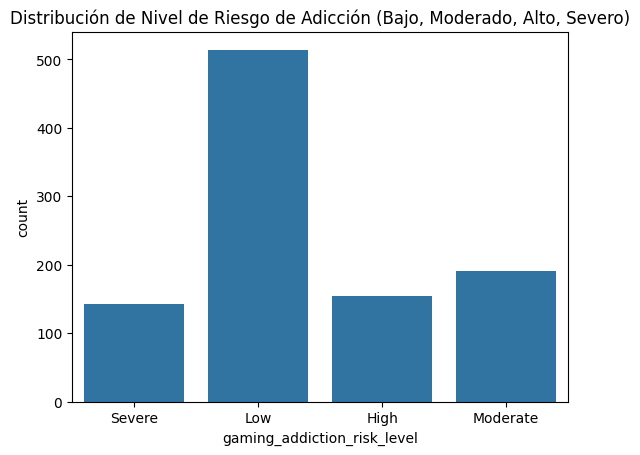

In [ ]:
print("Visualización Inicial:")
display(df_encuestas.head())
print("Valores Nulos por Columna:")
display(df_encuestas.isnull().sum())

# Distribución de la clase objetivo (ej. 'Gaming_Addiction_Level' o similar)
sns.countplot(data=df_encuestas, x='gaming_addiction_risk_level')
plt.title('Distribución de Nivel de Riesgo de Adicción (Bajo, Moderado, Alto, Severo)')
plt.show()

## ⋅ Feature Engineering

In [ ]:
# Rellenar Valores Nulos
for col in df_encuestas.select_dtypes(include=np.number).columns:
  df_encuestas[col] = df_encuestas[col].fillna(df_encuestas[col].median())

# Codificar Variables Categóricas
le = LabelEncoder()
for col in df_encuestas.select_dtypes(include=['object']).columns:
  df_encuestas[col] = le.fit_transform(df_encuestas[col])

# Separar Características (X) y Variable Objetivo (y)
X_conductual = df_encuestas.drop('gaming_addiction_risk_level', axis=1)
y_conductual = df_encuestas['gaming_addiction_risk_level']

# División de Datos en Train/Test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_conductual, y_conductual, test_size=0.3, random_state=42)

# Escalado
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.fit_transform(X_test_c)

## ⋅ Entrenamiento y Métricas

--- Resultados Regresión Logística ---
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        52
           1       1.00      1.00      1.00       148
           2       0.88      1.00      0.93        50
           3       1.00      0.86      0.92        50

    accuracy                           0.95       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.96      0.95      0.95       300

--- Coeficientes Regresión Logística ---


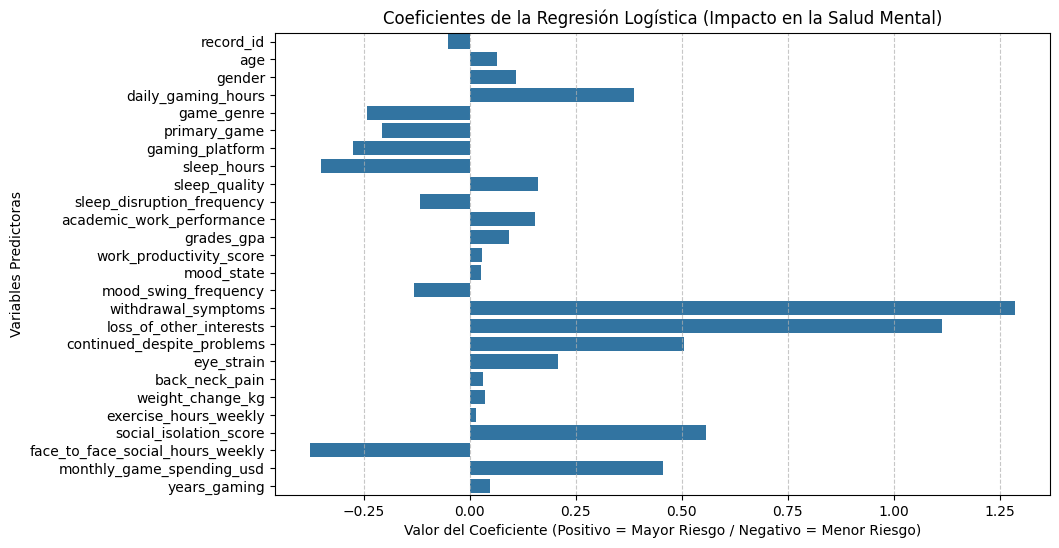

Matriz de Confusión (Regresión Logística)


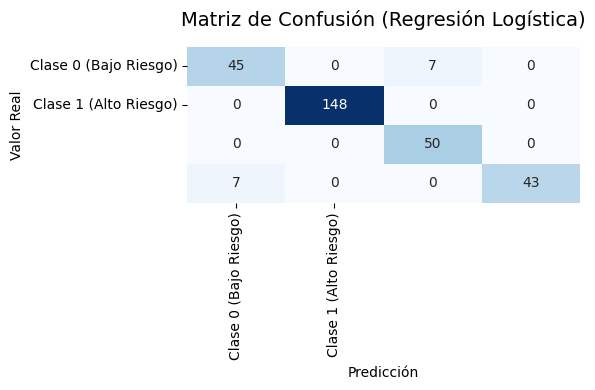

--- Resultados Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.81      0.83        52
           1       1.00      0.99      1.00       148
           2       0.84      0.94      0.89        50
           3       0.96      0.92      0.94        50

    accuracy                           0.94       300
   macro avg       0.91      0.92      0.91       300
weighted avg       0.94      0.94      0.94       300

--- Importancia Variables Predictoras (Random Forest) ---


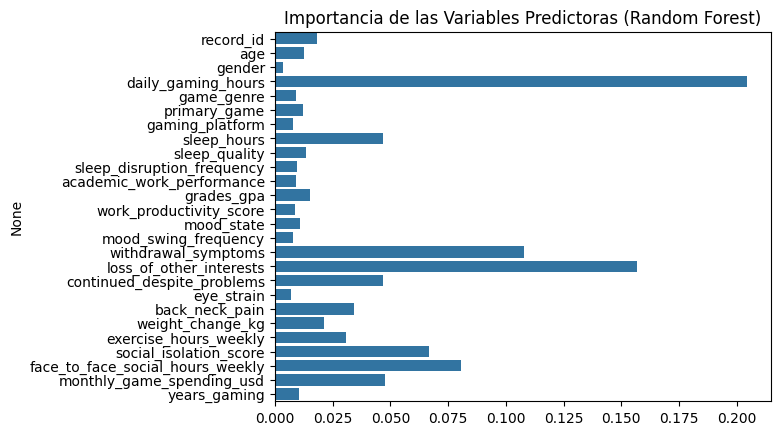

Matriz de Confusión (Random Forest)


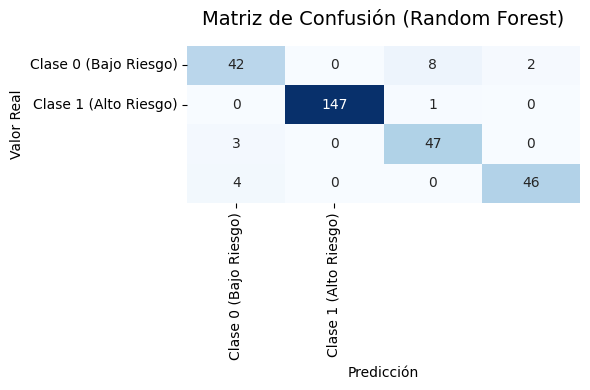

--- Resultados KNN --
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        52
           1       0.90      0.99      0.94       148
           2       0.67      0.56      0.61        50
           3       0.94      0.68      0.79        50

    accuracy                           0.82       300
   macro avg       0.78      0.73      0.75       300
weighted avg       0.82      0.82      0.81       300

Matriz de Confusión (KNN)


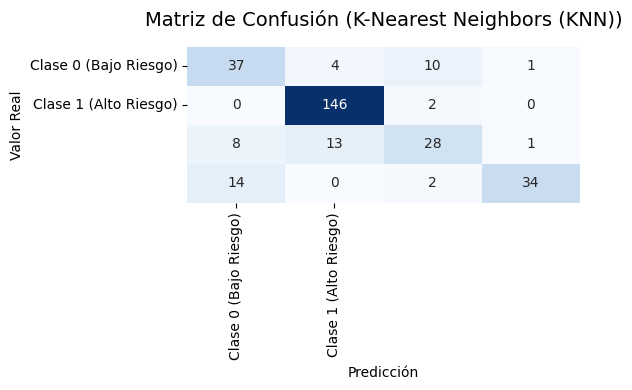

In [ ]:
# --- Regresión Logística (Conductual) ---
lr_conductual = LogisticRegression(max_iter=1000, random_state=42)
lr_conductual.fit(X_train_c_scaled, y_train_c)
y_pred_lr_c = lr_conductual.predict(X_test_c_scaled)

print("--- Resultados Regresión Logística ---")
print(classification_report(y_test_c, y_pred_lr_c))

print("--- Coeficientes Regresión Logística ---")
importances_lr = lr_conductual.coef_[0]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_lr, y=X_conductual.columns)
plt.title('Coeficientes de la Regresión Logística (Impacto en la Salud Mental)')
plt.xlabel('Valor del Coeficiente (Positivo = Mayor Riesgo / Negativo = Menor Riesgo)')
plt.ylabel('Variables Predictoras')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Matriz de Confusión (Regresión Logística)")
generar_matriz_confusion(y_test_c, y_pred_lr_c, "Regresión Logística")

# --- Entrenamiento Random Forest ---
rf_conductual = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_conductual.fit(X_train_c_scaled, y_train_c)
y_pred_rf_c = rf_conductual.predict(X_test_c_scaled)

print("--- Resultados Random Forest ---")
print(classification_report(y_test_c, y_pred_rf_c))

print("--- Importancia Variables Predictoras (Random Forest) ---")
importances_rf = rf_conductual.feature_importances_
sns.barplot(x=importances_rf, y=X_conductual.columns)
plt.title("Importancia de las Variables Predictoras (Random Forest)")
plt.show()

print("Matriz de Confusión (Random Forest)")
generar_matriz_confusion(y_test_c, y_pred_rf_c, "Random Forest")

# --- Entrenamiento KNN (Conductual) ---
knn_conductual = KNeighborsClassifier(n_neighbors=5)
knn_conductual.fit(X_train_c_scaled, y_train_c)
y_pred_knn_c = knn_conductual.predict(X_test_c_scaled)

print("--- Resultados KNN --")
print(classification_report(y_test_c, y_pred_knn_c))

print("Matriz de Confusión (KNN)")
generar_matriz_confusion(y_test_c, y_pred_knn_c, "K-Nearest Neighbors (KNN)")